In [56]:
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from build_labels import build_labels
from mouseDataset import MouseDataset
from training import *
from experiment import *
from saliency_map import *
from experiment_modified import *
from visualization_functions import *
from gradcam_functions import visualize_gradcam


In [29]:
PROJECT_DIR = Path.cwd()

BASE_DIR = PROJECT_DIR / "mouse_dataset"
IMG_DIR = BASE_DIR / "images_perfect"

MGS_CSV = BASE_DIR / "MouseGrimaceFaces_mgs.csv"
MAIN_CSV = BASE_DIR / "MouseGrimaceFaces_main.csv"

# 02 Muzzle-only Classification

这个 notebook 使用 `mouse_dataset/muzzle_crops` 里面已经裁剪好的 muzzle 图片来训练分类模型。  
核心逻辑和 full-image classification 相同，区别是：

- full image classification 读取 `mouse_dataset/images`
- muzzle-only classification 读取 `mouse_dataset/muzzle_crops`
- 只保留已经成功 crop 的图片

## select impared images & save (optional)

In [23]:
from build_labels import copy_impaired_images

df = build_labels(
    MGS_CSV,
    MAIN_CSV,
    IMG_DIR
)

copy_impaired_images(
    df,
    "mouse_dataset/image_impaired"
)

Rows before crop filtering: 3406
Rows after crop filtering:  1398
Removed because crop image missing: 2008
Copied 631 impaired images to:
mouse_dataset/image_impaired


## sample visualization (option)

In [24]:
# 当前已分配的内存torch.mps.empty_cache()
print(f"已分配内存: {torch.mps.current_allocated_memory() / 1024**3:.2f} GiB")
# 驱动程序分配的总内存
print(f"驱动分配总量: {torch.mps.driver_allocated_memory() / 1024**3:.2f} GiB")

print("Current directory:", PROJECT_DIR)
print("Dataset path:", BASE_DIR)
print("MGS exists:", MGS_CSV.exists())
print("MAIN exists:", MAIN_CSV.exists())
print("Muzzle crop folder exists:", IMG_DIR.exists())
print("Number of crop images:", len(list(IMG_DIR.glob("*.jpg"))) + len(list(IMG_DIR.glob("*.png"))))


print("Total usable muzzle-crop images:", len(df))
print("Label distribution:")
print(df["label"].value_counts())

print("Subset distribution:")
print(df["subset"].value_counts())

df.head()


已分配内存: 0.00 GiB
驱动分配总量: 0.00 GiB
Current directory: /Users/baturu/Documents/Project_CV
Dataset path: /Users/baturu/Documents/Project_CV/mouse_dataset
MGS exists: True
MAIN exists: True
Muzzle crop folder exists: True
Number of crop images: 1398
Total usable muzzle-crop images: 1398
Label distribution:
label
0    767
1    631
Name: count, dtype: int64
Subset distribution:
subset
KH    427
MR    399
JW    277
LW    212
AW     83
Name: count, dtype: int64


,index,subset,id,path,mgs_mean,label
0,000008.jpg,KH,94,/Users/baturu/Documents/Project_CV/mouse_datas...,0.200000,0
1,000009.jpg,KH,94,/Users/baturu/Documents/Project_CV/mouse_datas...,0.642857,0
2,000015.jpg,JW,202,/Users/baturu/Documents/Project_CV/mouse_datas...,0.533333,0
3,000027.jpg,JW,119,/Users/baturu/Documents/Project_CV/mouse_datas...,1.071429,1
4,000031.jpg,KH,110,/Users/baturu/Documents/Project_CV/mouse_datas...,0.400000,0


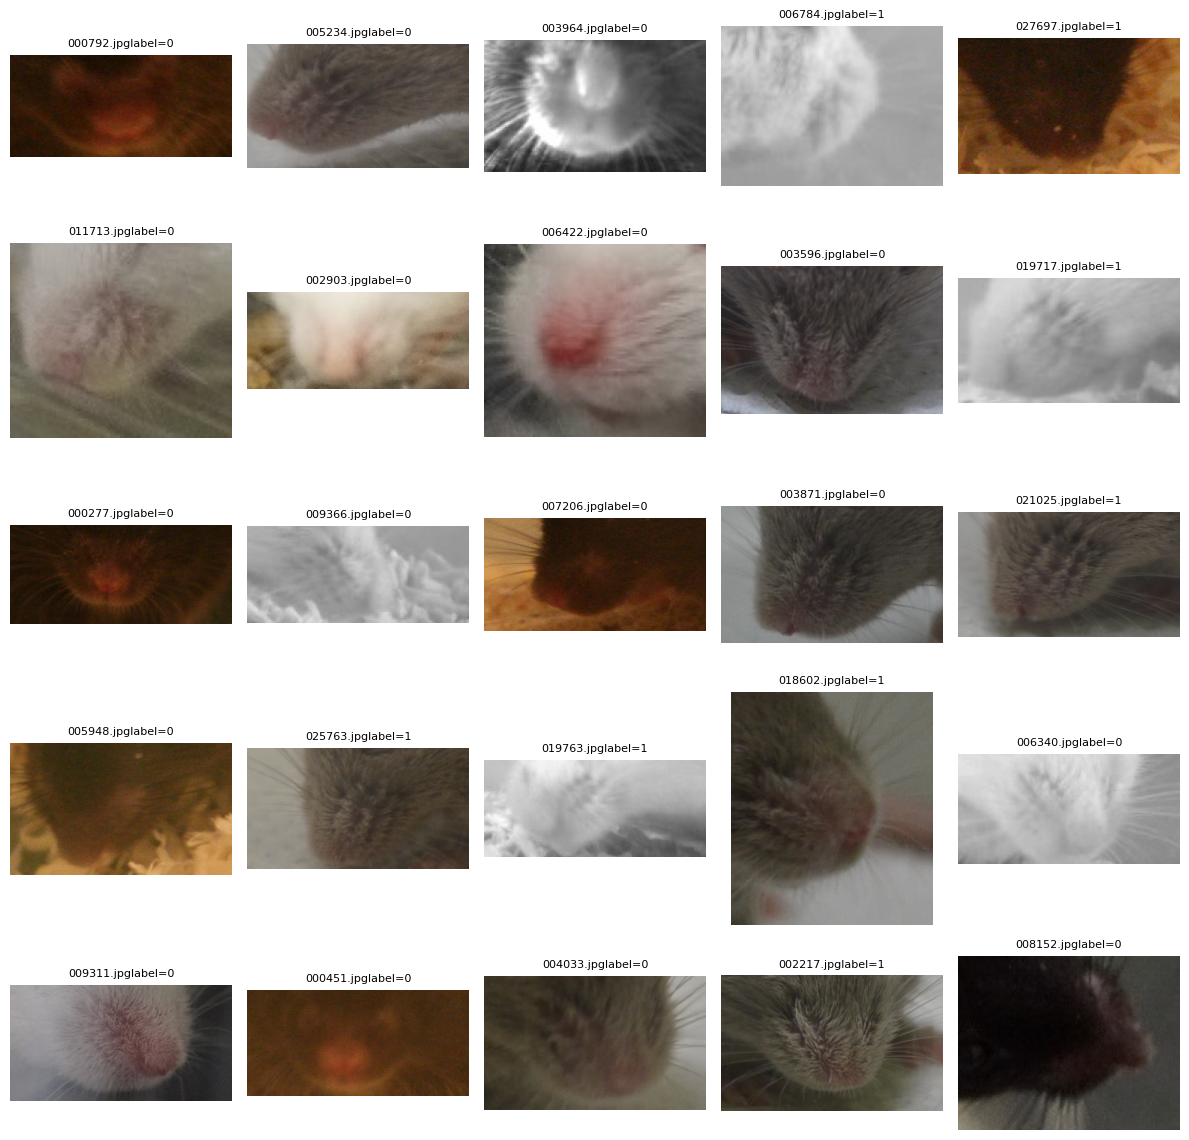

In [7]:
# Optional: visualize random muzzle crops before training

sample_df = df.sample(n=min(25, len(df)), random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f'{row["index"]}label={row["label"]}', fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))

print("Train label distribution:")
print(train_df["label"].value_counts())

print("Validation label distribution:")
print(val_df["label"].value_counts())

Train size: 1112
Validation size: 286
Train label distribution:
label
0    622
1    490
Name: count, dtype: int64
Validation label distribution:
label
0    145
1    141
Name: count, dtype: int64


In [ ]:
model, history = run_training(
    train_df=train_df,
    val_df=val_df,
    dataset_class=MouseDataset,
    train_one_epoch_fn=train_one_epoch,
    evaluate_fn=evaluate,
    save_path="mouse_wellbeing_convnext_tiny.pt",
    epochs=10,
    batch_size=50,
    lr=1e-4,
    weight_decay=1e-4
)

# use lr schedule

In [30]:
PROJECT_DIR = Path.cwd()

BASE_DIR = PROJECT_DIR / "mouse_dataset"
IMG_DIR = BASE_DIR / "images_perfect"

MGS_CSV = BASE_DIR / "MouseGrimaceFaces_mgs.csv"
MAIN_CSV = BASE_DIR / "MouseGrimaceFaces_main.csv"

In [31]:
df = build_labels(MGS_CSV, MAIN_CSV, IMG_DIR)
# We split by mouse identity, not by individual image.
# This avoids putting images from the same mouse in both train and validation.
train_df, val_df = make_group_split(df)

Rows before crop filtering: 3406
Rows after crop filtering:  1398
Removed because crop image missing: 2008



Using device: mps

Epoch 1/10
Current LR: 0.00001000


Validation: 100%|██████████| 15/15 [00:06<00:00,  2.43it/s]


Train loss: 0.6072233462972301
Validation macro_f1: 0.7412

Confusion matrix:
[[104  41]
 [ 33 108]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.76      0.72      0.74       145
    impaired       0.72      0.77      0.74       141

    accuracy                           0.74       286
   macro avg       0.74      0.74      0.74       286
weighted avg       0.74      0.74      0.74       286

Saved best model to best_muzzle_image_model_v1.pt
New best model: epoch=1, macro_f1=0.7412

Epoch 2/10
Current LR: 0.00001000


Validation: 100%|██████████| 15/15 [00:07<00:00,  2.06it/s]


Train loss: 0.512829201562064
Validation macro_f1: 0.7549

Confusion matrix:
[[103  42]
 [ 28 113]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.79      0.71      0.75       145
    impaired       0.73      0.80      0.76       141

    accuracy                           0.76       286
   macro avg       0.76      0.76      0.75       286
weighted avg       0.76      0.76      0.75       286

Saved best model to best_muzzle_image_model_v1.pt
New best model: epoch=2, macro_f1=0.7549

Epoch 3/10
Current LR: 0.00001000


...

Train loss: 0.33975578072879997
Validation macro_f1: 0.7832

Confusion matrix:
[[110  35]
 [ 27 114]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.80      0.76      0.78       145
    impaired       0.77      0.81      0.79       141

    accuracy                           0.78       286
   macro avg       0.78      0.78      0.78       286
weighted avg       0.78      0.78      0.78       286

Learning rate reduced: 0.00001000 -> 0.00000500
No improvement. Early-stopping counter: 3/5

Epoch 9/10
Current LR: 0.00000500


Validation: 100%|██████████| 15/15 [00:05<00:00,  2.55it/s]


Train loss: 0.3206132147461176
Validation macro_f1: 0.7723

Confusion matrix:
[[117  28]
 [ 37 104]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.76      0.81      0.78       145
    impaired       0.79      0.74      0.76       141

    accuracy                           0.77       286
   macro avg       0.77      0.77      0.77       286
weighted avg       0.77      0.77      0.77       286

No improvement. Early-stopping counter: 4/5

Epoch 10/10
Current LR: 0.00000500


Validation: 100%|██████████| 15/15 [00:07<00:00,  2.04it/s]


Train loss: 0.2918710274887936
Validation macro_f1: 0.7827

Confusion matrix:
[[119  26]
 [ 36 105]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.77      0.82      0.79       145
    impaired       0.80      0.74      0.77       141

    accuracy                           0.78       286
   macro avg       0.78      0.78      0.78       286
weighted avg       0.78      0.78      0.78       286

No improvement. Early-stopping counter: 5/5

Early stopping triggered. Best epoch: 5, best macro_f1: 0.7937

Loaded best model from epoch 5 with macro_f1=0.7937


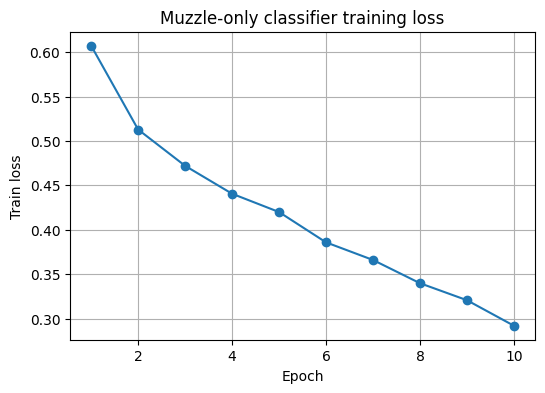

In [32]:
model, history = run_training_with_lr_schedule_early_stop_best_model(
    train_df=train_df,
    val_df=val_df,
    dataset_class=MouseDataset,
    train_one_epoch_fn=train_one_epoch,
    evaluate_fn=evaluate,
    save_path="best_muzzle_image_model_v1.pt",
    epochs=10,
    batch_size=20,
    lr=1e-5,
    metric_name="macro_f1",
    scheduler_patience=2,
    early_stopping_patience=5
)

history_df = pd.DataFrame(history)

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Muzzle-only classifier training loss")
plt.grid(True)
plt.show()

## plotting

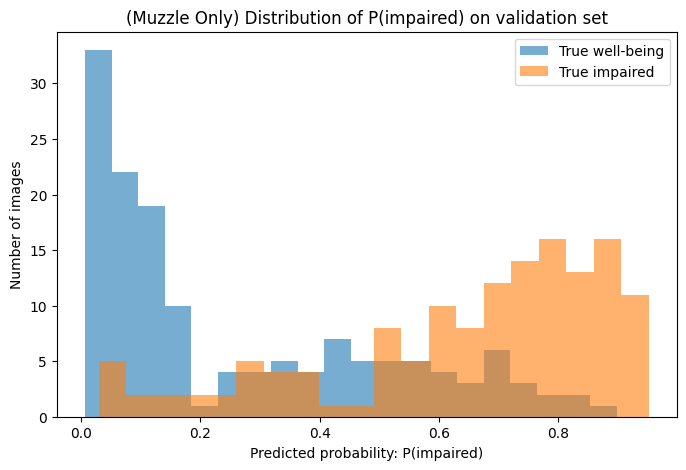

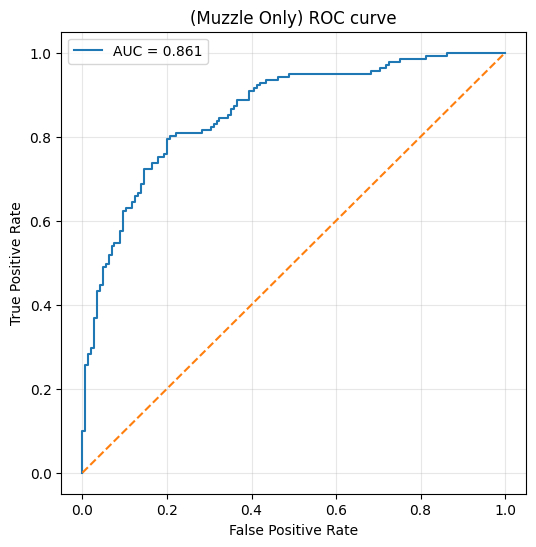

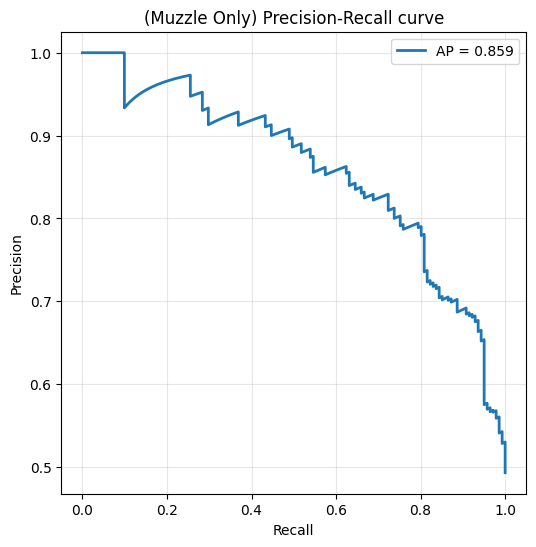

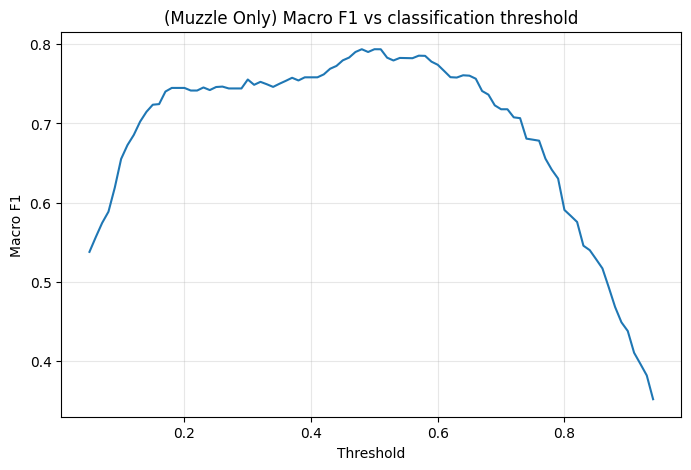

AUC: 0.8605
Average precision: 0.8592
Best threshold: 0.48
Best macro F1: 0.7937
Saved figures to: output


In [35]:
from visualization_functions import visualize_binary_classifier_results

train_loader, val_loader = build_dataloaders(
    train_df=train_df,
    val_df=val_df,
    dataset_class=MouseDataset,
    batch_size=32,
    image_size=224
)

results = visualize_binary_classifier_results(
    model=model,
    val_loader=val_loader,
    evaluate_with_probs_fn=evaluate_with_probs,
    output_dir="output",
    prefix="muzzle_only",
    title_prefix="Muzzle Only"
)

## use grad cam saliency map

### 导入gradcam

In [ ]:
_, val_tfms = build_transforms()

visualize_gradcam(
    model=model,
    val_df=val_df,
    dataset_class=MouseDataset,
    target_layer=model.features[-1][-1].block[-1],
    output_dir="output/gradcam",
    num_images=5,
    transform=val_tfms
)

### 手搓grad cam

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(
            self.save_activation
        )
        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, img_tensor, device, target_class=None):
        self.model.eval()

        img = img_tensor.unsqueeze(0).to(device)
        output = self.model(img)

        pred_class = output.argmax(dim=1).item()

        if target_class is None:
            target_class = pred_class

        score = output[0, target_class]

        self.model.zero_grad()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, pred_class, target_class

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


def show_gradcam(
    model,
    dataset,
    index,
    device,
    gradcam,
    target_class=None,
    class_names=None
):
    if class_names is None:
        class_names = ["well-being", "impaired"]

    img_tensor, true_label = dataset[index]

    cam, pred_class, used_class = gradcam(
        img_tensor=img_tensor,
        device=device,
        target_class=target_class
    )

    img = denormalize(img_tensor)

    cam_resized = F.interpolate(
        torch.tensor(cam).unsqueeze(0).unsqueeze(0),
        size=img.shape[:2],
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {class_names[int(true_label)]}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_resized, cmap="jet")
    plt.title(f"Grad-CAM\nClass: {class_names[used_class]}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(cam_resized, cmap="jet", alpha=0.45)
    plt.title(f"Overlay\nPred: {class_names[pred_class]}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================
# Build validation dataset
# ==========================
device = get_device()
_, val_tfms = build_transforms()

val_ds = MouseDataset(
    val_df,
    transform=val_tfms
)

# ==========================
# Create GradCAM object
# ==========================

target_layer = model.features[-1][-1].block[-1]

gradcam = GradCAM(
    model=model,
    target_layer=target_layer
)

number_of_images_2_show = 50 
for idx in range(number_of_images_2_show):
    show_gradcam(
        model=model,
        dataset=val_ds,
        index=idx,
        device=device,
        gradcam=gradcam,
        target_class=None
    )

# Fullimage

In [42]:
# folder where current script exists
PROJECT_DIR = Path.cwd()
BASE_DIR = PROJECT_DIR / "mouse_dataset"
IMG_DIR = BASE_DIR / "images_mgs"
MGS_CSV = BASE_DIR / "MouseGrimaceFaces_mgs.csv"
MAIN_CSV = BASE_DIR / "MouseGrimaceFaces_main.csv"

In [43]:
df2 = build_labels(MGS_CSV, MAIN_CSV, IMG_DIR)
train_df2, val_df2 = make_group_split(df2)

Rows before crop filtering: 3406
Rows after crop filtering:  3024
Removed because crop image missing: 382



Using device: mps

Epoch 1/5
Current LR: 0.00001000


Validation: 100%|██████████| 36/36 [00:17<00:00,  2.10it/s]


Train loss: 0.4392694642401149
Validation macro_f1: 0.8017

Confusion matrix:
[[511  22]
 [ 69  99]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.88      0.96      0.92       533
    impaired       0.82      0.59      0.69       168

    accuracy                           0.87       701
   macro avg       0.85      0.77      0.80       701
weighted avg       0.87      0.87      0.86       701

Saved best model to best_full_image_model.pt
New best model: epoch=1, macro_f1=0.8017

Epoch 2/5
Current LR: 0.00001000


Validation: 100%|██████████| 36/36 [00:15<00:00,  2.31it/s]


Train loss: 0.2897974900328196
Validation macro_f1: 0.8477

Confusion matrix:
[[486  47]
 [ 33 135]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.94      0.91      0.92       533
    impaired       0.74      0.80      0.77       168

    accuracy                           0.89       701
   macro avg       0.84      0.86      0.85       701
weighted avg       0.89      0.89      0.89       701

Saved best model to best_full_image_model.pt
New best model: epoch=2, macro_f1=0.8477

Epoch 3/5
Current LR: 0.00001000


...

Train loss: 0.24268343108586776
Validation macro_f1: 0.8541

Confusion matrix:
[[494  39]
 [ 36 132]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.93      0.93      0.93       533
    impaired       0.77      0.79      0.78       168

    accuracy                           0.89       701
   macro avg       0.85      0.86      0.85       701
weighted avg       0.89      0.89      0.89       701

Saved best model to best_full_image_model.pt
New best model: epoch=3, macro_f1=0.8541

Epoch 4/5
Current LR: 0.00001000


Validation: 100%|██████████| 36/36 [00:18<00:00,  1.99it/s]


Train loss: 0.21342917694113192
Validation macro_f1: 0.8591

Confusion matrix:
[[497  36]
 [ 36 132]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.93      0.93      0.93       533
    impaired       0.79      0.79      0.79       168

    accuracy                           0.90       701
   macro avg       0.86      0.86      0.86       701
weighted avg       0.90      0.90      0.90       701

Saved best model to best_full_image_model.pt
New best model: epoch=4, macro_f1=0.8591

Epoch 5/5
Current LR: 0.00001000


Validation: 100%|██████████| 36/36 [00:17<00:00,  2.01it/s]


Train loss: 0.19190232764579293
Validation macro_f1: 0.8646

Confusion matrix:
[[511  22]
 [ 44 124]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.92      0.96      0.94       533
    impaired       0.85      0.74      0.79       168

    accuracy                           0.91       701
   macro avg       0.89      0.85      0.86       701
weighted avg       0.90      0.91      0.90       701

Saved best model to best_full_image_model.pt
New best model: epoch=5, macro_f1=0.8646

Loaded best model from epoch 5 with macro_f1=0.8646


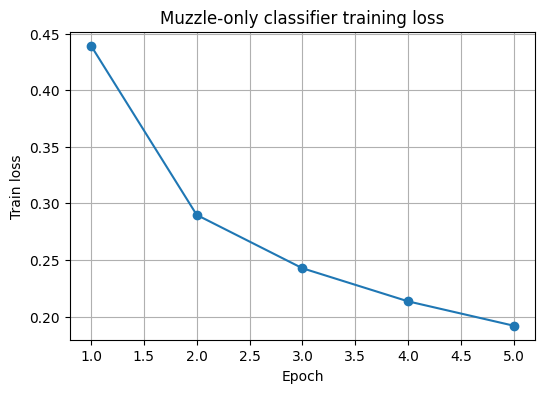

In [45]:
model2, history2 = run_training_with_lr_schedule_early_stop_best_model(
    train_df=train_df2,
    val_df=val_df2,
    dataset_class=MouseDataset,
    train_one_epoch_fn=train_one_epoch,
    evaluate_fn=evaluate,
    save_path="best_full_image_model.pt",
    epochs=5,
    batch_size=20,
    lr=1e-5,
    metric_name="macro_f1",
    scheduler_patience=2,
    early_stopping_patience=5
)

history_df = pd.DataFrame(history2)

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Muzzle-only classifier training loss")
plt.grid(True)
plt.show()

## plotting

In [ ]:
from visualization_functions import visualize_binary_classifier_results

train_loader2, val_loader2 = build_dataloaders(
    train_df=train_df,
    val_df=val_df,
    dataset_class=MouseDataset,
    batch_size=32,
    image_size=224
)

results = visualize_binary_classifier_results(
    model=model2,
    val_loader=val_loader2,
    evaluate_with_probs_fn=evaluate_with_probs,
    output_dir="output",
    prefix="full_image",
    title_prefix="full_image"
)

## grad cam

In [52]:
_, val_tfms = build_transforms()

visualize_gradcam(
    model=model2,
    val_df=val_df2,
    dataset_class=MouseDataset,
    target_layer=model2.features[-1][-1].block[-1],
    output_dir="output/gradcam",
    num_images=5,
    transform=val_tfms
)

{'saved_images': 5,
 'checked_images': 5,
 'correct_saved': 5,
 'wrong_saved': 0,
 'output_dir': 'output/gradcam',
 'results': [{'index': 0,
   'true_label': 1,
   'pred_class': 1,
   'target_class': 1,
   'true_name': 'impaired',
   'pred_name': 'impaired',
   'target_name': 'impaired',
   'correct': True,
   'probabilities': array([0.05582196, 0.944178  ], dtype=float32),
   'save_path': 'output/gradcam/gradcam_0000_true_impaired_pred_impaired_target_impaired_correct.png'},
  {'index': 1,
   'true_label': 0,
   'pred_class': 0,
   'target_class': 0,
   'true_name': 'well-being',
   'pred_name': 'well-being',
   'target_name': 'well-being',
   'correct': True,
   'probabilities': array([0.97109354, 0.02890646], dtype=float32),
   'save_path': 'output/gradcam/gradcam_0001_true_well-being_pred_well-being_target_well-being_correct.png'},
  {'index': 2,
   'true_label': 0,
   'pred_class': 0,
   'target_class': 0,
   'true_name': 'well-being',
   'pred_name': 'well-being',
   'target_name